# CONDITIONAL EXPECTATION

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Necessary parameters:
n = 100000
Y = np.random.uniform(0, 1, n)
# Simulate X|Y ~ Uniform(0, Y^2)
X = np.random.uniform(0, 1, n) * Y**2  # why does this work? u=F(x); u=(x-a)/(b-a) -> x=ub-ua+a, where a=0, so x=ub, u~Unif(0,1), b=Y^2

In [27]:
print('E[X|Y] = ', np.mean(X))
print('Var(X|Y) = ', np.var(X))

E[X|Y] =  0.16628194103974422
Var(X|Y) =  0.03887970478638792


In [28]:
# Binning Y into 20 equal intervals
bins = np.linspace(0, 1, 21) # need to cut into 21 to get 20 intervals
digitized = np.digitize(Y, bins)
bin_means = [X[digitized == i].mean() for i in range(1, len(bins))] # average of each bin
bin_expectation = np.mean(bin_means) #sum of each bin then /20
bin_var = [X[digitized == i].var() for i in range(1, len(bins))] 
bin_variance = np.mean(bin_var) + np.var(bin_means)

In [29]:
print(len(bin_means))
print('average of 20 bins', bin_expectation)
print('variance of 20 bins', bin_variance)

20
average of 20 bins 0.1665579908358174
variance of 20 bins 0.03884610208866228


# LLN

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Necessary parameters:
np.random.seed(42)
n_max = 5000
mu = 1

# Three distributions
exp_samples = np.random.exponential(scale=1, size=n_max)    # mu=1
unif_samples = np.random.uniform(0, 2, size=n_max)          # mu=1
poisson_samples = np.random.poisson(lam=1, size=n_max)      # mu=1

# Compute running mean for each
ns = np.arange(1, n_max+1)
# running mean of exponential:
running_mean_exp = np.cumsum(exp_samples) / ns
running_mean_unif = np.cumsum(unif_samples) / ns
running_mean_pois = np.cumsum(poisson_samples) / ns

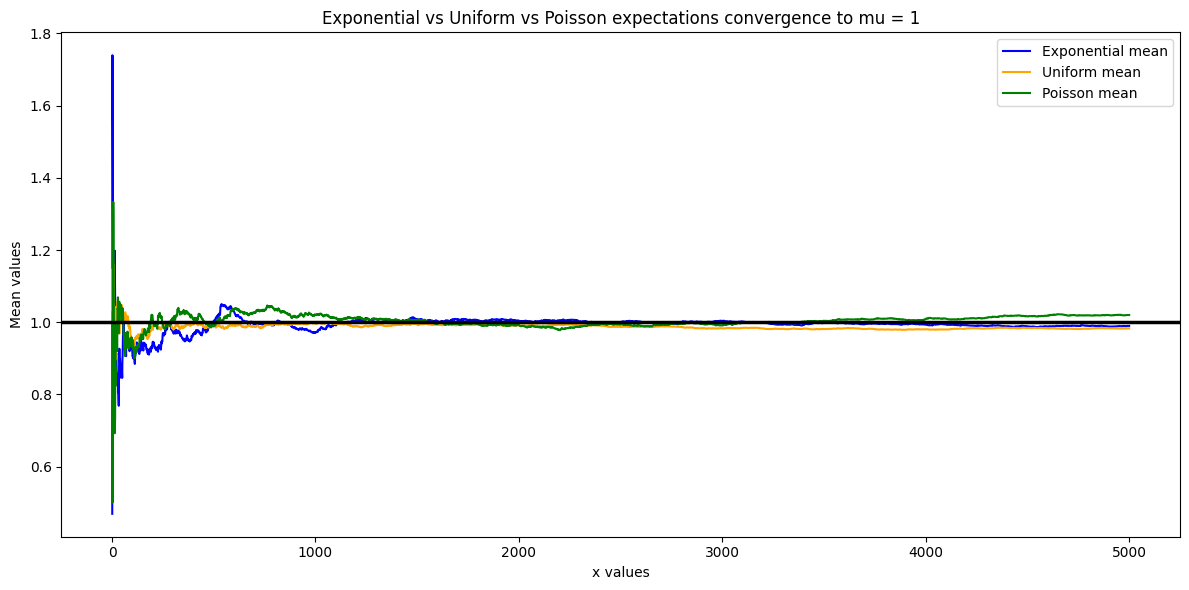

In [50]:
#1. Plotting all 3 RVs:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ns, running_mean_exp, color='blue', lw=1.5, 
        label=f'Exponential mean')
ax.plot(ns, running_mean_unif, color = 'orange', lw = 1.5,
       label = f'Uniform mean')
ax.plot(ns, running_mean_pois, color = 'green', lw = 1.5,
       label = f'Poisson mean')
ax.axhline(y=1, xmin = 0, xmax = 4, color = 'black', lw = 2.5)
ax.set_xlabel('x values')
ax.set_ylabel('Mean values')
ax.set_title(f'Exponential vs Uniform vs Poisson expectations convergence to mu = 1')
ax.legend()
plt.tight_layout()
plt.show()

In [52]:
print('Exponential Variance / n : ', np.var(exp_samples)/n_max)
print('Uniform Variance / n : ', np.var(unif_samples)/n_max)
print('Poisson Variance / n : ', np.var(poisson_samples)/n_max)

Exponential Variance / n :  0.00019481501491538665
Uniform Variance / n :  6.524838002578803e-05
Poisson Variance / n :  0.00020768


# CLT

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Necessary parameters:
n_sim = 5000
mu = 0
sigma = 1


# Three distributions
exp_samples = np.random.exponential(scale=1, size=n_max)    # mu=1
norm_Z = np.random.normal(mu, sigma, n_sim)
x_Z = np.linspace(-4, 4, 300)
# Calculate the theoretical y-values using the Normal PDF formula
pdf_Z = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_Z - mu) / sigma)**2)

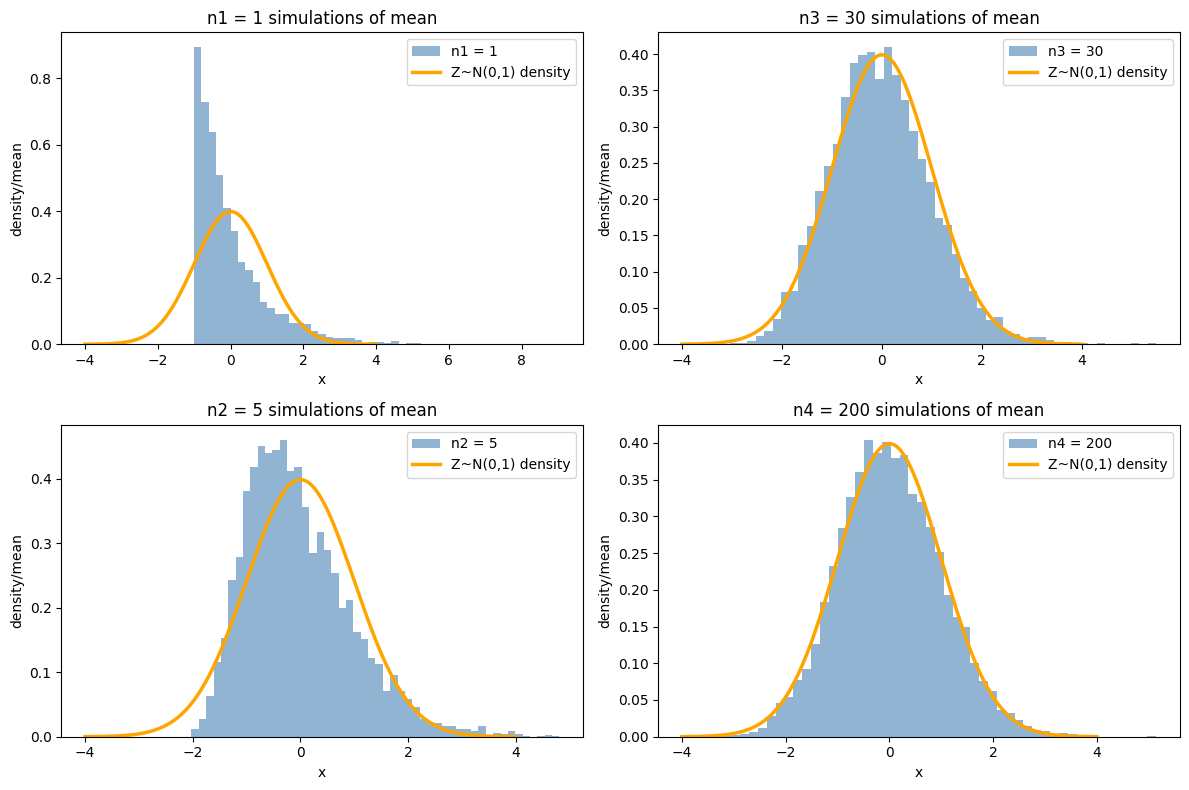

In [82]:
n1 = 1
n2 = 5
n3 = 30
n4 = 200

exp_X1 = np.random.exponential(scale=1, size=(n_sim, n1))
exp_X2 = np.random.exponential(scale=1, size=(n_sim, n2))
exp_X3 = np.random.exponential(scale=1, size=(n_sim, n3))
exp_X4 = np.random.exponential(scale=1, size=(n_sim, n4))

std_mean_Zn1 = (np.mean(exp_X1, axis=1) - 1) / (1/np.sqrt(n1))
std_mean_Zn2 = (np.mean(exp_X2, axis=1) - 1) / (1/np.sqrt(n2))
std_mean_Zn3 = (np.mean(exp_X3, axis=1) - 1) / (1/np.sqrt(n3))
std_mean_Zn4 = (np.mean(exp_X4, axis=1) - 1) / (1/np.sqrt(n4))

# Universal preset for 4 - Plots:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# n1=1 Histogram
axes[0, 0].hist(std_mean_Zn1, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='n1 = 1')

# Z~N(0,1) Theoretical pdf-Curve
axes[0, 0].plot(x_Z, pdf_Z, 
        color='orange', lw=2.5, label=f'Z~N(0,1) density')

axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('density/mean')
axes[0, 0].set_title(f'n1 = 1 simulations of mean')
axes[0, 0].legend()

############################

# n2=5 Histogram
axes[1, 0].hist(std_mean_Zn2, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='n2 = 5')

# Z~N(0,1) Theoretical pdf-Curve
axes[1, 0].plot(x_Z, pdf_Z, 
        color='orange', lw=2.5, label=f'Z~N(0,1) density')

axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('density/mean')
axes[1, 0].set_title(f'n2 = 5 simulations of mean')
axes[1, 0].legend()

############################

# n3=30 Histogram
axes[0, 1].hist(std_mean_Zn3, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='n3 = 30')

# Z~N(0,1) Theoretical pdf-Curve
axes[0, 1].plot(x_Z, pdf_Z, 
        color='orange', lw=2.5, label=f'Z~N(0,1) density')

axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('density/mean')
axes[0, 1].set_title(f'n3 = 30 simulations of mean')
axes[0, 1].legend()

############################

# n4=200 Histogram
axes[1, 1].hist(std_mean_Zn4, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='n4 = 200')

# Z~N(0,1) Theoretical pdf-Curve
axes[1, 1].plot(x_Z, pdf_Z, 
        color='orange', lw=2.5, label=f'Z~N(0,1) density')

axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('density/mean')
axes[1, 1].set_title(f'n4 = 200 simulations of mean')
axes[1, 1].legend()

################### PLOT SHOW  ##############################
plt.tight_layout()
plt.show()

# Bayesian Inference

In [16]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Prior: Gamma(alpha=3, beta=1)
alpha_prior = 3
beta_prior = 1
true_lambda = 4  # true value we're trying to estimate
n=20
# Simulate observations one at a time
np.random.seed(42)
observations = np.random.poisson(true_lambda, size=n)

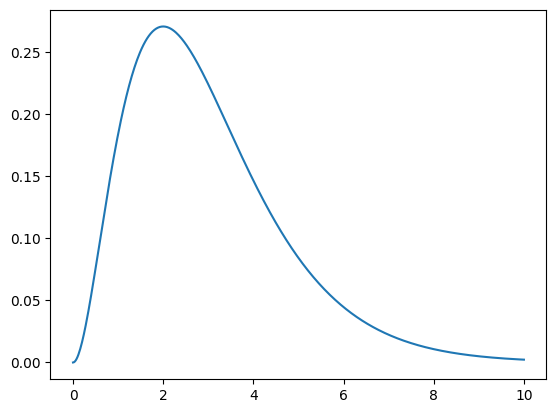

In [20]:
# Plot priors
x_vals = np.linspace(0, 10, 500) # x-axis: potential values of lambda
prior_pdf = stats.gamma.pdf(x_vals, a=alpha_prior, scale=1/beta_prior) # y-axis
plt.plot(x_vals, prior_pdf, label="Prior")

In [22]:
#Expectation of Prior Gamma
prior_expectation = alpha_prior / beta_prior

# alpha updates: prior + sum of observations so far
alpha_posteriors = alpha_prior + np.cumsum(observations)

# beta updates: prior + number of observations so far (n)
# np.arange(1, 21) gives us [1, 2, 3... 20]
beta_posteriors = beta_prior + np.arange(1, 21)

[8 4 4 4 2 5 2 5 3 5 7 1 4 3 3 0 5 4 6 7]
[11 15 19 23 25 30 32 37 40 45 52 53 57 60 63 63 68 72 78 85]
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


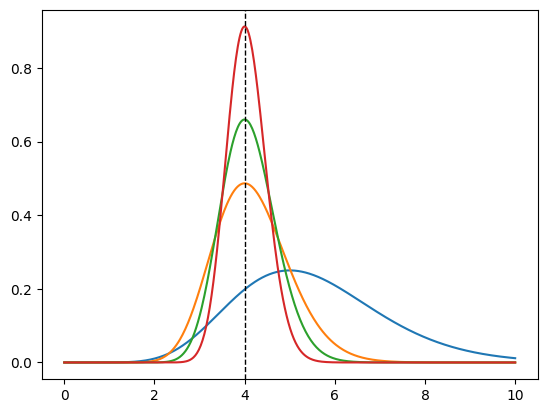

In [41]:
# Plot posteriors
prior_pdf_1 = stats.gamma.pdf(x_vals, a=alpha_posteriors[0], scale=1/beta_posteriors[0]) # y-axis
plt.plot(x_vals, prior_pdf_1, label="Posterior after 1")

prior_pdf_5 = stats.gamma.pdf(x_vals, a=alpha_posteriors[4], scale=1/beta_posteriors[4]) # y-axis
plt.plot(x_vals, prior_pdf_5, label="Posterior after 5")

prior_pdf_10 = stats.gamma.pdf(x_vals, a=alpha_posteriors[9], scale=1/beta_posteriors[9]) # y-axis
plt.plot(x_vals, prior_pdf_10, label="Posterior after 10")

prior_pdf_20 = stats.gamma.pdf(x_vals, a=alpha_posteriors[19], scale=1/beta_posteriors[19]) # y-axis
plt.plot(x_vals, prior_pdf_20, label="Posterior after 20")

plt.axvline(x = true_lambda, ymin=0, ymax = 1, color = 'black', lw = 1.0, ls = '--')

In [42]:
# Posterior expectation:
posteriors_expectation = alpha_posteriors / beta_posteriors
print(posteriors_expectation)

[5.5        5.         4.75       4.6        4.16666667 4.28571429
 4.         4.11111111 4.         4.09090909 4.33333333 4.07692308
 4.07142857 4.         3.9375     3.70588235 3.77777778 3.78947368
 3.9        4.04761905]


In [43]:
# Posterior variance:
posteriors_variance = alpha_posteriors / (beta_posteriors**2)
print(posteriors_variance)

[2.75       1.66666667 1.1875     0.92       0.69444444 0.6122449
 0.5        0.45679012 0.4        0.37190083 0.36111111 0.31360947
 0.29081633 0.26666667 0.24609375 0.21799308 0.20987654 0.19944598
 0.195      0.19274376]
